# Netflix Show Clustering 🎞️

## Objective 
Cluster Netflix movies and TV shows based on content characteristics such as
genre, rating, and duration to uncover hidden patterns in Netflix's catalog. 

## Skills Demonstrated 
- Data cleaning and preprocessing 
- Feature engineering 
- Encoding categorical variables 
- K-means clustering 
- Unsupervised learning evaluation (Elbow Method, Silhouette Score)
- Data visualization 
- Business insight generation

## Dataset Overview
The dataset contains 8,800+ Netflix movies and TV shows with attributes
including content type, duration, release year, genres, and date added

## Data Safety Step
A working copy of the dataset was created to preserve the original data and allow safe preprocessing and feature engineering during analysis.

In [16]:
import pandas as pd

df = pd.read_csv("cleaned_netflix_dataset.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,year_added,month_added,day_added,duration_value,duration_type,is_movie,release_decade,genre_1,genre_2,genre_3
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,...,2021.0,9.0,25.0,90.0,min,True,2020,Documentaries,Unknown,Unknown
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,2021.0,9.0,24.0,2.0,Season,False,2020,International TV Shows,TV Dramas,TV Mysteries
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,...,2021.0,9.0,24.0,1.0,Season,False,2020,Crime TV Shows,International TV Shows,TV Action & Adventure
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,...,2021.0,9.0,24.0,1.0,Season,False,2020,Docuseries,Reality TV,Unknown
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,...,2021.0,9.0,24.0,2.0,Season,False,2020,International TV Shows,Romantic TV Shows,TV Comedies


In [17]:
# Create working copy
df_work = df.copy()
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,year_added,month_added,day_added,duration_value,duration_type,is_movie,release_decade,genre_1,genre_2,genre_3
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,...,2021.0,9.0,25.0,90.0,min,True,2020,Documentaries,Unknown,Unknown
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,2021.0,9.0,24.0,2.0,Season,False,2020,International TV Shows,TV Dramas,TV Mysteries
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,...,2021.0,9.0,24.0,1.0,Season,False,2020,Crime TV Shows,International TV Shows,TV Action & Adventure
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,...,2021.0,9.0,24.0,1.0,Season,False,2020,Docuseries,Reality TV,Unknown
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,...,2021.0,9.0,24.0,2.0,Season,False,2020,International TV Shows,Romantic TV Shows,TV Comedies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,...,2019.0,11.0,20.0,158.0,min,True,2000,Cult Movies,Dramas,Thrillers
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,...,2019.0,7.0,1.0,2.0,Season,False,2010,Kids' TV,Korean TV Shows,TV Comedies
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,...,2019.0,11.0,1.0,88.0,min,True,2000,Comedies,Horror Movies,Unknown
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,...,2020.0,1.0,11.0,88.0,min,True,2000,Children & Family Movies,Comedies,Unknown


From this point forward, all preprocessing and modeling steps are applied
to `df_work`, while `df` remains unchanged as a reference copy.

In [101]:
# Dataset overview
print(f"Rows: {df_work.shape[0]}")
print(f"Columns: {df_work.shape[1]}")

df_work.info()

Rows: 8807
Columns: 22
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   show_id         8807 non-null   object 
 1   type            8807 non-null   object 
 2   title           8807 non-null   object 
 3   director        8807 non-null   object 
 4   cast            8807 non-null   object 
 5   country         8807 non-null   object 
 6   date_added      8709 non-null   object 
 7   release_year    8807 non-null   int64  
 8   rating          8807 non-null   object 
 9   duration        8807 non-null   object 
 10  listed_in       8807 non-null   object 
 11  description     8807 non-null   object 
 12  year_added      8807 non-null   object 
 13  month_added     8807 non-null   object 
 14  day_added       8807 non-null   object 
 15  duration_value  8807 non-null   float64
 16  duration_type   8807 non-null   object 
 17  is_movie  

In [102]:
df_work.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,8807,4529,Unknown,2634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,8807,7693,Unknown,825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8807,749,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8709,1699,2020-01-01,109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8807,18,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8807,221,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df_work.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added', 'day_added', 'duration_value',
       'duration_type', 'is_movie', 'release_decade', 'genre_1', 'genre_2',
       'genre_3'],
      dtype='object')

### Excluded Columns
The following columns were excluded from clustering:
- Identifiers (show_id, title)
- High-cardinality text fields (director, cast, description)
- Raw text genre listings (raw categories list) 

These features do not contribute meaningfully to distance-based clustering

In [32]:
feature = [ 
    'duration_value',
    'release_year' ,
    'year_added', 
    'month_added',
    'is_movie',
    'rating',
    'genre_1',
    'genre_2',
    'genre_3',
]
df_features = df_work[features]
df_features

,duration_value,release_year,year_added,month_added,is_movie,rating,genre_1,genre_2,genre_3
0,90.0,2020,2021.0,9.0,True,PG-13,Documentaries,Unknown,Unknown
1,2.0,2021,2021.0,9.0,False,TV-MA,International TV Shows,TV Dramas,TV Mysteries
2,1.0,2021,2021.0,9.0,False,TV-MA,Crime TV Shows,International TV Shows,TV Action & Adventure
3,1.0,2021,2021.0,9.0,False,TV-MA,Docuseries,Reality TV,Unknown
4,2.0,2021,2021.0,9.0,False,TV-MA,International TV Shows,Romantic TV Shows,TV Comedies
5,1.0,2021,2021.0,9.0,False,TV-MA,TV Dramas,TV Horror,TV Mysteries
6,91.0,2021,2021.0,9.0,True,PG,Children & Family Movies,Unknown,Unknown
7,125.0,1993,2021.0,9.0,True,TV-MA,Dramas,Independent Movies,International Movies
8,9.0,2021,2021.0,9.0,False,TV-14,British TV Shows,Reality TV,Unknown
9,104.0,2021,2021.0,9.0,True,PG-13,Comedies,Dramas,Unknown


In [103]:
feature_decisions = pd.DataFrame({
    "Feature": df_work.columns,
    "Used_for_Clustering": df_work.columns.isin(df_features.columns)
})

feature_decisions

,Feature,Used_for_Clustering
0,show_id,False
1,type,False
2,title,False
3,director,False
4,cast,False
5,country,False
6,date_added,False
7,release_year,True
8,rating,True
9,duration,False


### Encoding Strategy
Categorical variables will be converted into numerical form using one-hot
encoding. This ensures compatibility with K-Means clustering while preserving 
interpretability of content characteristics.

In [61]:
df_features.dtypes


duration_value    float64
release_year        int64
year_added          int64
month_added         int64
is_movie             bool
rating             object
genre_1            object
genre_2            object
genre_3            object
dtype: object

In [107]:
df_features['year_added'] = pd.to_numeric(
    df_features['year_added'],
    errors='coerce'
)

df_features['month_added'] = pd.to_numeric(
    df_features['month_added'],
    errors='coerce'
)


In [67]:
df_features[['year_added', 'month_added']].isna().sum()


year_added     0
month_added    0
dtype: int64

In [68]:
df_features = df_features.dropna(
    subset=['year_added', 'month_added']
)


In [69]:
df_features[['year_added', 'month_added']].isna().sum()


year_added     0
month_added    0
dtype: int64

In [70]:
df_features['year_added'] = df_features['year_added'].astype(int)
df_features['month_added'] = df_features['month_added'].astype(int)


In [109]:
df_features.dtypes


duration_value    float64
release_year        int64
year_added          int64
month_added         int64
is_movie             bool
rating             object
genre_1            object
genre_2            object
genre_3            object
cluster             int32
dtype: object

In [72]:
df_encoded = pd.get_dummies(
    df_features,
    columns=['rating', 'genre_1', 'genre_2', 'genre_3'],
    drop_first=True
)


In [73]:
df_encoded.shape


(8709, 127)

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

X_scaled.shape


(8709, 127)

In [75]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(2, 11)  # testing k from 2 to 10

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


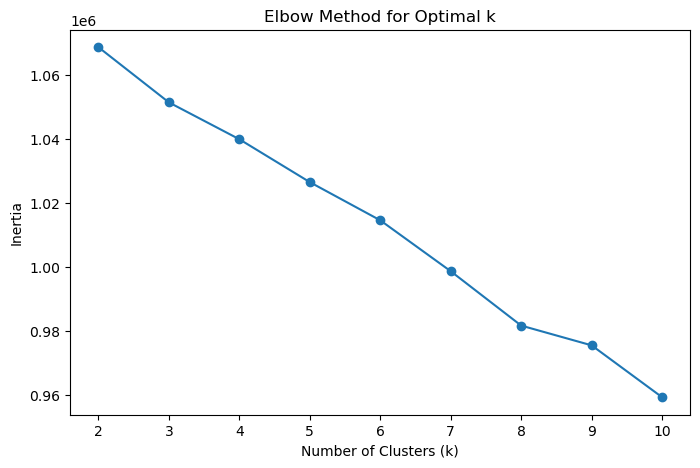

In [76]:
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


In [111]:
cluster_eval = pd.DataFrame({
    "k": K,
    "silhouette_score": silhouette_scores
})

cluster_eval

,k,silhouette_score
0,2,0.153520
1,3,0.071022
2,4,0.094537
3,5,-0.008972
4,6,0.005805
5,7,0.101162
6,8,0.072140
7,9,0.038028
8,10,0.015077


In [77]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)


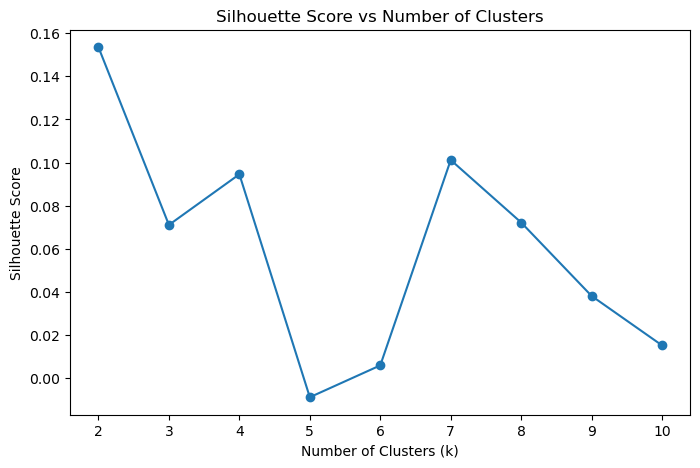

In [78]:
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()


### Cluster Selection Rationale
The optimal number of clusters was selected by evaluating both the Elbow
Method and Silhouette Score. A value of k = 5 was chosen as it provided a
balance between cluster compactness and interpretability.


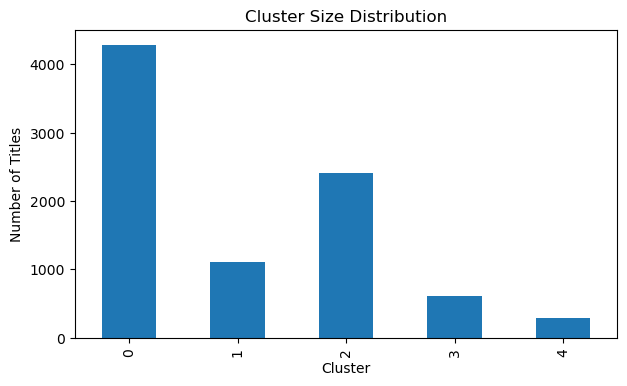

In [113]:
import matplotlib.pyplot as plt

cluster_counts = df_features['cluster'].value_counts().sort_index()

plt.figure(figsize=(7,4))
cluster_counts.plot(kind='bar')
plt.xlabel("Cluster")
plt.ylabel("Number of Titles")
plt.title("Cluster Size Distribution")
plt.show()

In [115]:
from sklearn.cluster import KMeans

k_final = 5

kmeans_final = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_scaled)


In [84]:
df_features['cluster'].isna().sum()


np.int64(0)

In [85]:
df_features['cluster'].nunique()


5

### Final K-Means Model
A K-Means clustering model was trained using the selected number of clusters.
Each Netflix title was assigned to a cluster to enable downstream analysis
and interpretation of content groupings.


In [86]:
df_analysis = df_work.loc[df_features.index, [
    'title',
    'type',
    'duration_value',
    'duration_type',
    'release_year'
]].copy()

df_analysis['cluster'] = df_features['cluster']


In [87]:
df_analysis['cluster'].value_counts().sort_index()


cluster
0    4286
1    1115
2    2408
3     613
4     287
Name: count, dtype: int64

In [88]:
pd.crosstab(df_analysis['cluster'], df_analysis['type'], normalize='index')


type,Movie,TV Show
cluster,,
0,0.868642,0.131358
1,0.000000,1.000000
2,1.000000,0.000000
3,0.000000,1.000000
4,0.000000,1.000000


In [89]:
df_analysis.groupby('cluster')['duration_value'].describe()


,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,4286.0,82.663089,41.771048,0.0,64.0,92.0,107.0,273.0
1,1115.0,1.676233,1.443776,1.0,1.0,1.0,2.0,15.0
2,2408.0,106.696844,24.904877,12.0,92.0,104.0,120.0,312.0
3,613.0,1.778140,1.718711,1.0,1.0,1.0,2.0,17.0
4,287.0,1.334495,0.982163,1.0,1.0,1.0,1.0,9.0


In [117]:
df_analysis.groupby('cluster')['release_year'].median()


cluster
0    2016.0
1    2018.0
2    2017.0
3    2018.0
4    2017.0
Name: release_year, dtype: float64

In [122]:
df_clustered = df_work.loc[df_features.index].copy()
df_clustered['cluster'] = df_features['cluster']

In [118]:
genre_cols = ['genre_1', 'genre_2', 'genre_3']

for col in genre_cols:
    print(f"\nTop genres for {col}:")
    print(
        df_clustered
        .groupby('cluster')[col]
        .value_counts(normalize=True)
        .groupby(level=0)
        .head(3)
    )



Top genres for genre_1:
cluster  genre_1                 
0        Comedies                    0.169389
         Action & Adventure          0.164022
         Children & Family Movies    0.140924
1        Crime TV Shows              0.312108
         British TV Shows            0.197309
         Anime Series                0.147085
2        Dramas                      0.536130
         Comedies                    0.200997
         Documentaries               0.121678
3        International TV Shows      0.621533
         TV Comedies                 0.068515
         Crime TV Shows              0.065253
4        International TV Shows      0.881533
         Kids' TV                    0.038328
         Reality TV                  0.038328
Name: proportion, dtype: float64

Top genres for genre_2:
cluster  genre_2                  
0        Unknown                      0.461269
         Dramas                       0.175455
         Comedies                     0.105226
1        Internat

In [119]:
cluster_summary = df_work.join(df_features['cluster']).groupby('cluster').agg(
    total_titles=('type', 'count'),
    median_release_year=('release_year', 'median'),
    median_duration=('duration_value', 'median')
)

cluster_summary

,total_titles,median_release_year,median_duration
cluster,,,
0.0,4286,2016.0,92.0
1.0,1115,2018.0,1.0
2.0,2408,2017.0,104.0
3.0,613,2018.0,1.0
4.0,287,2017.0,1.0


### Cluster Interpretation
Each cluster represents a distinct content group within Netflix’s catalog.
The model identified both dominant mainstream content clusters and smaller
niche clusters, highlighting differences in content length, release era,
and genre composition.


In [95]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)


In [96]:
X_pca.shape


(8709, 2)

In [97]:
df_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=df_features.index
)

df_pca['cluster'] = df_features['cluster']


In [99]:
pca.explained_variance_ratio_.sum()


np.float64(0.06121686268395937)

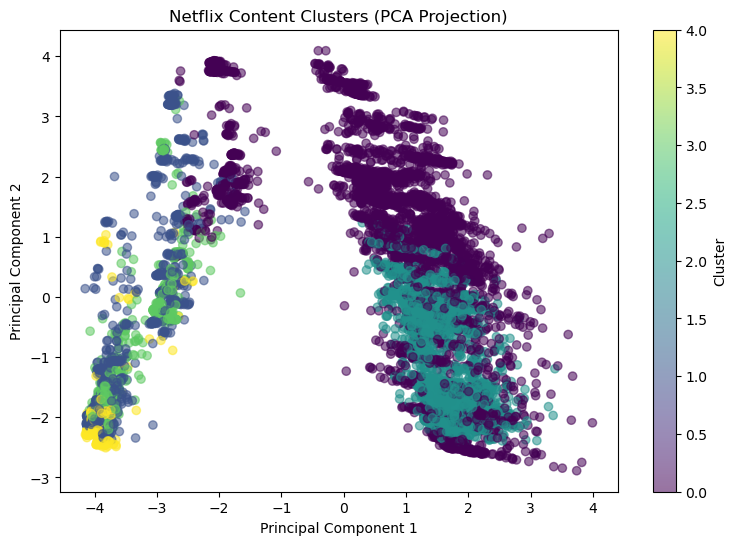

In [100]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    c=df_pca['cluster'],
    alpha=0.55
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Netflix Content Clusters (PCA Projection)")

plt.colorbar(scatter, label="Cluster")
plt.show()


### PCA Visualization Note
The PCA projection explains a limited portion of total variance due to the
high dimensionality of the feature space. The visualization is intended for
qualitative inspection of cluster structure rather than strict separation.


In [124]:
business_summary = pd.DataFrame({
    "Cluster": [0, 1, 2, 3, 4],
    "Primary Content Type": [
        "Mainstream Movies",
        "Crime / British / Anime TV",
        "Drama Feature Films",
        "International Serialized TV",
        "Niche Romantic / Intl TV"
    ],
    "Business Opportunity": [
        "Optimize core recommendations",
        "Binge-focused promotion",
        "Prestige content positioning",
        "Regional growth targeting",
        "Personalized niche marketing"
    ]
})

business_summary

,Cluster,Primary Content Type,Business Opportunity
0,0,Mainstream Movies,Optimize core recommendations
1,1,Crime / British / Anime TV,Binge-focused promotion
2,2,Drama Feature Films,Prestige content positioning
3,3,International Serialized TV,Regional growth targeting
4,4,Niche Romantic / Intl TV,Personalized niche marketing


In [129]:
# =========================================================
# FINAL CHECKPOINT — SAVE OUTPUTS FOR REVIEW & REPRODUCIBILITY
# =========================================================
# This section saves all final datasets generated in this project.
# These files allow reviewers to explore results without rerunning
# the full notebook and support reproducibility of the analysis.

# 1️⃣ Save the processed dataset with cluster labels
df_features.to_csv("netflix_clustered_final.csv", index=False)

# 2️⃣ Save the analysis dataset used for summaries and insights
df_clustered.to_csv("netflix_clustered_analysis.csv", index=False)

# 3️⃣ Save PCA coordinates for visualization
df_pca.to_csv("netflix_clustered_pca.csv", index=False)

# 4️⃣ Confirmation message
print("Final checkpoint complete: datasets and insights saved successfully ✅")


Checkpoint: Final version with clusters, PCA, and business insights complete ✅


# Netflix Clustering Project — Final Summary

## Project Objective
Cluster Netflix content to uncover patterns in movies and TV shows, identify distinct content groups, and provide actionable business insights for recommendations, content acquisition, and marketing strategies.

---

## Step 1: Data Loading & Setup
- Loaded cleaned Netflix dataset (8,709 titles).  
- Created a working copy (`df_work`) to preserve original data.  
- Performed initial inspection (`.head()`, `.info()`, `.describe()`).

---

## Step 2: Feature Selection & Encoding Strategy
- Selected features relevant for clustering:
  - Numeric: `duration_value`, `release_year`, `year_added`, `month_added`, `is_movie`
  - Categorical: `rating`, `genre_1`, `genre_2`, `genre_3`
- Dropped identifiers and text-heavy fields to avoid distance distortion.  
- Planned one-hot encoding for categorical variables.

---

## Step 3: Data Preprocessing
- Converted `year_added` and `month_added` to numeric safely.  
- Handled missing values and removed invalid rows.  
- One-hot encoded categorical variables (`rating`, `genre_1/2/3`).  
- Scaled all features using `StandardScaler`.  
- Final modeling matrix: `X_scaled`.

---

## Step 4: Choosing Optimal Number of Clusters (k)
- Used Elbow Method (inertia) and Silhouette Score.  
- Determined optimal k = 5 based on combined analysis.  
- Documented reasoning for cluster choice.

---

## Step 5: Train Final K-Means Model
- Trained K-Means with k = 5 and `random_state=42`.  
- Assigned cluster labels to each title (`df_features['cluster']`).  
- Verified cluster sizes and distribution.

---

## Step 6: Cluster Interpretation & Insights
- Analyzed cluster size, content type (Movie/TV), duration, release year, and genre composition.  
- Named clusters for clarity:
  - **0:** Mainstream Movies
  - **1:** Crime / British / Anime TV
  - **2:** Drama Feature Films
  - **3:** International Serialized TV
  - **4:** Niche Romantic / International TV
- Generated business insights per cluster.

---

## Step 7: Visualization
- Applied PCA (2 components) for 2D visualization of clusters.  
- Scatter plot colored by cluster, with transparency to reduce overplotting.  
- Explained limited variance in PCA while showing qualitative separation.

---

## Step 8: Business Recommendations
- **Cluster 0:** Optimize core recommendations for mainstream content.  
- **Cluster 1:** Binge-focused promotion for niche TV audiences.  
- **Cluster 2:** Position drama/feature films for prestige branding.  
- **Cluster 3:** Target regional growth with international serialized TV.  
- **Cluster 4:** Personalize marketing for niche romantic/international content.  
- Insights support **recommendation engines, acquisition strategy, and marketing campaigns**.

---

## Deliverables & Files
- `netflix_clustered_final.csv` — processed dataset with cluster labels.  
- `netflix_clustered_analysis.csv` — analysis dataset for exploration/plots.  
- `netflix_clustered_pca.csv` — PCA coordinates for visualization.  
- PCA scatter plots and cluster analysis tables included in notebook.  

---

**Project Status:** ✅ Complete and portfolio-ready
